In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
product, time_reso, reso = 'IMERG', '1dy', '10'

In [3]:
dir_input = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'uncorrected')
dir_output = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'corrected')
obs_base = os.path.join('/','media','arturo','T9','Data','INTENSE','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [4]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
lon_min, lon_max, lat_min, lat_max, area = 12.25, 14, 45.5, 46.65, 'Friuli-Venezia Giulia'

In [5]:
# yys, yye = 2002, 2022
yys, yye = 2009, 2022

In [6]:
inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
DATA = xr.open_dataset(os.path.join(dir_input, 'quantiles_v2', inputfile))

DATA = DATA.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max),
    year=slice(yys, yye)
)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

MEV = DATA.Mev_s.where(mask_italy).values

In [7]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))

METADATA['Yr_Strt'] = pd.to_datetime(METADATA['Yr_Strt'])
METADATA['Yer_End'] = pd.to_datetime(METADATA['Yer_End'])

METADATA['YYs'] = METADATA['Yr_Strt'].dt.year
METADATA['YYe'] = METADATA['Yer_End'].dt.year
METADATA['Nyear'] = (METADATA['YYe']-METADATA['YYs'])+1

METADATA_CLEAR = METADATA[(METADATA['YYs'] <= yys)&(METADATA['YYe'] >= yye)]

# METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR.Nyear>19]

METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR['Region']=='Friuli-Venezia Giulia']

print(f'Number of Stations filtered: {len(METADATA_CLEAR)}')

Number of Stations filtered: 159


In [8]:
p_train, p_val = 100, 100
# p_train, p_val = 90, 10
# p_train, p_val = 80, 20
# p_train, p_val = 70, 30
# p_train, p_val = 50, 50

In [9]:
seed = 42

if p_train == 100:
    DF_80 = METADATA_CLEAR.copy()
    DF_20 = METADATA_CLEAR.copy()
elif p_train == 90:
    DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.10,random_state=seed,shuffle=True)
elif p_train == 80:
    DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.20,random_state=seed,shuffle=True)
elif p_train == 70:
    DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.30,random_state=seed,shuffle=True)
elif p_train == 50:
    DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.50,random_state=seed,shuffle=True)
print(f'Percetange to train: {p_train}%')

DF_80['color'] = 'royalblue'
DF_20['color'] = 'salmon'

METADATA_CLEAR.loc[DF_80.index, 'color'] = 'royalblue'
METADATA_CLEAR.loc[DF_20.index, 'color'] = 'salmon'

Percetange to train: 100%


Text(0, 0.5, 'Rain Gauges')

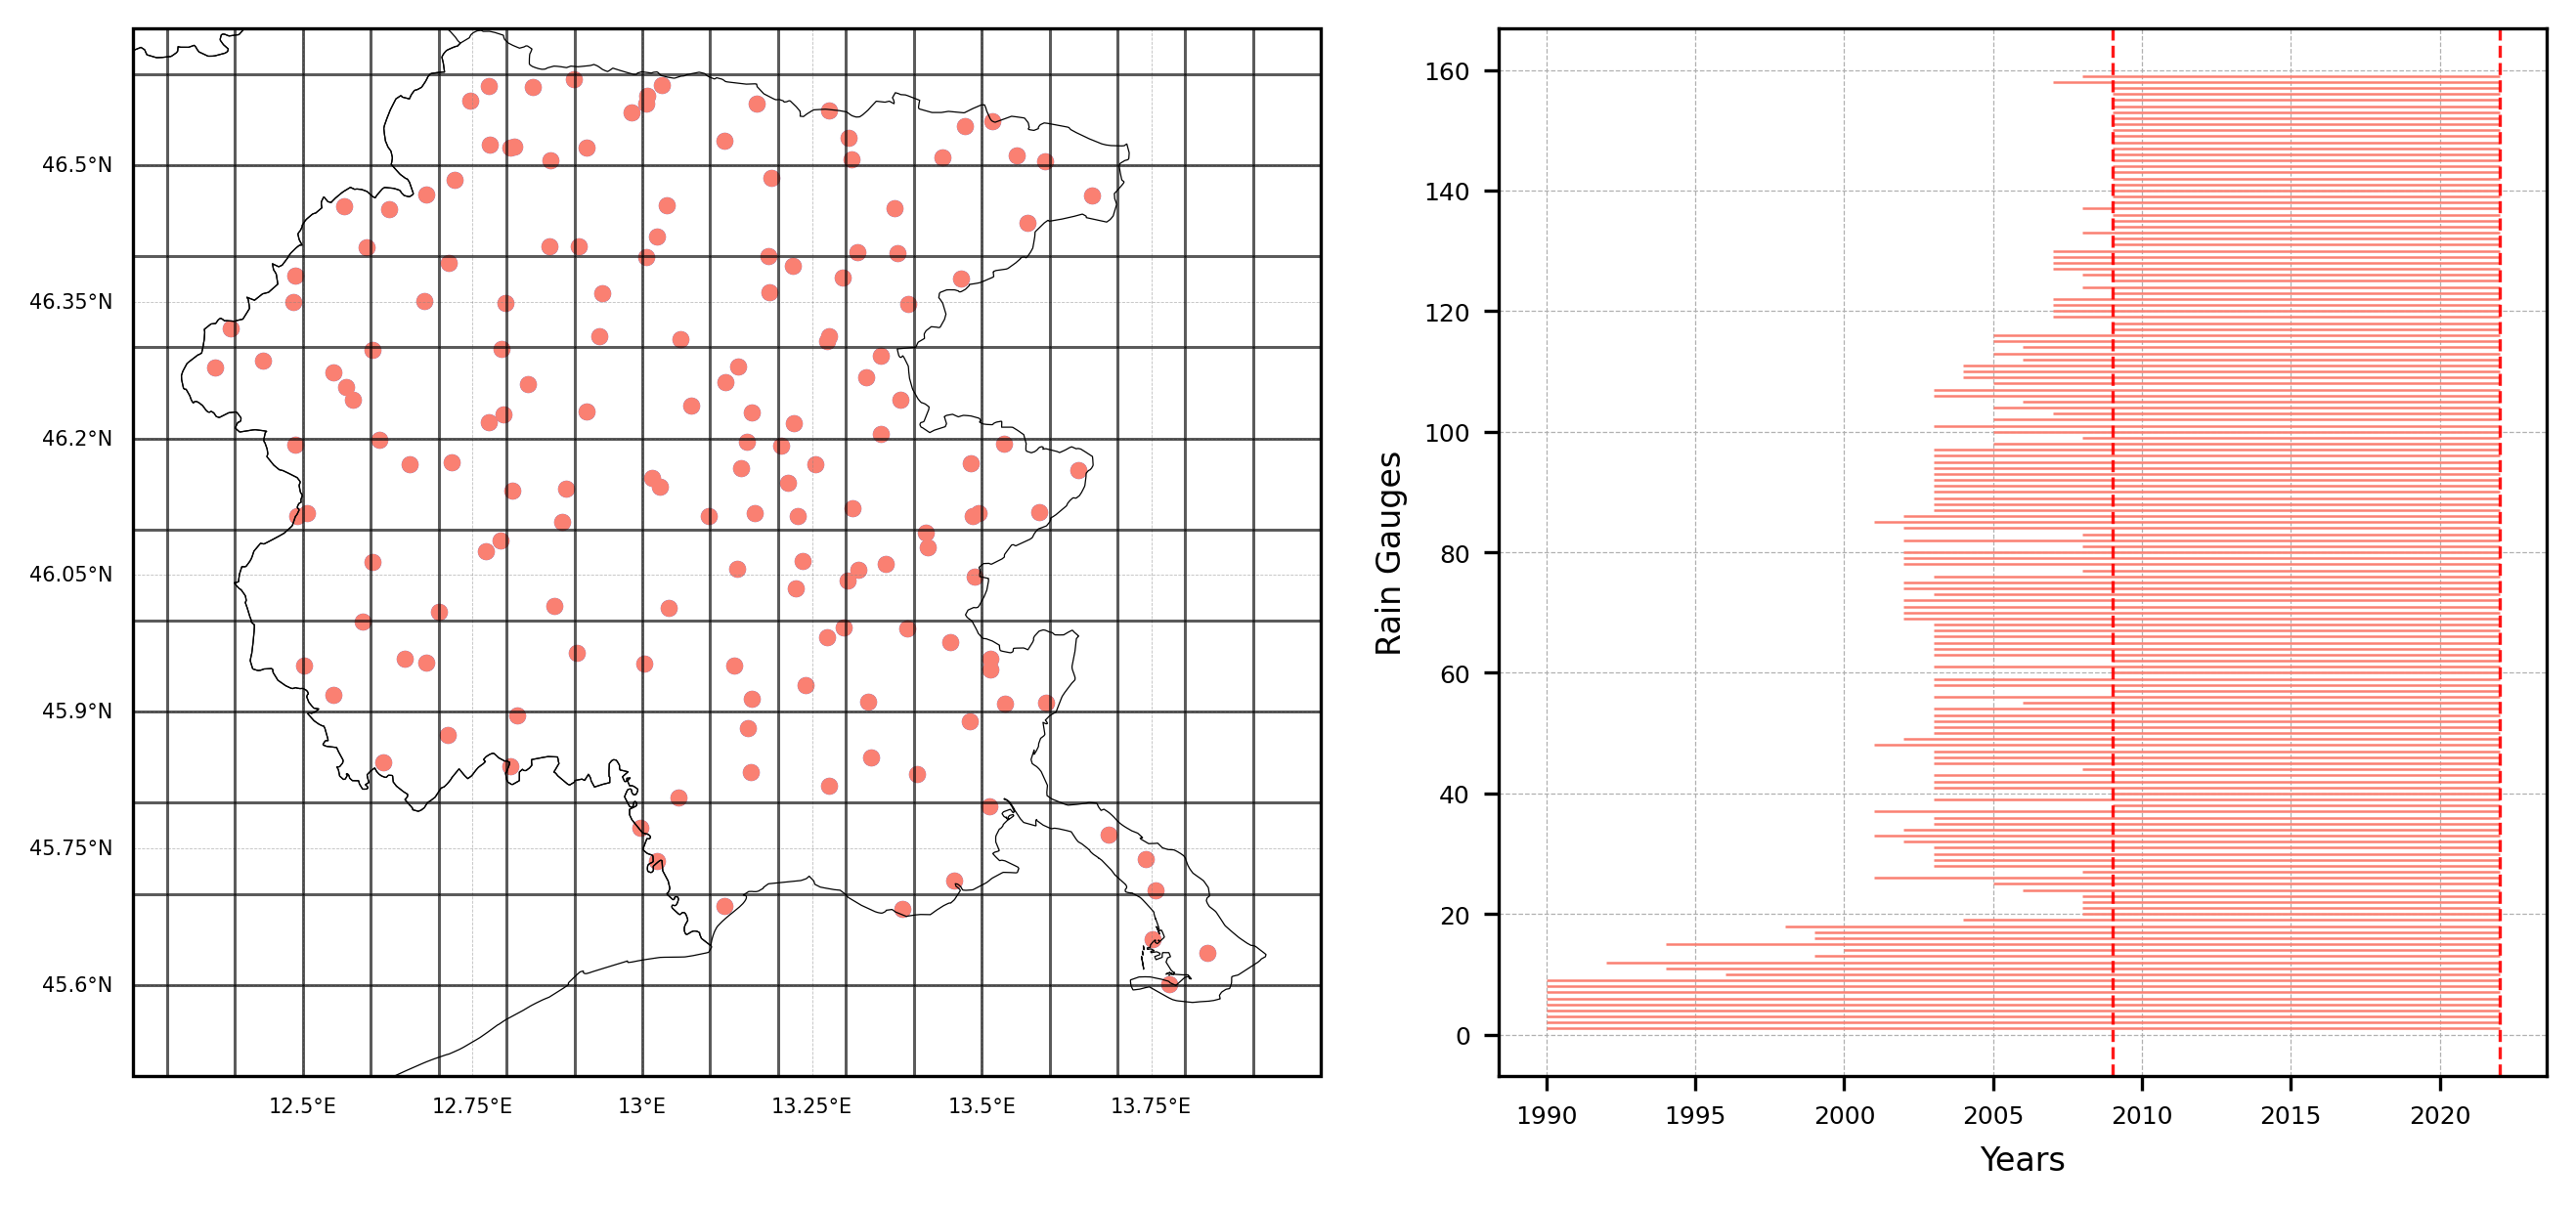

In [10]:
factor_levels = np.arange(0,2.5,0.1)
factor_norm = mcolors.BoundaryNorm(boundaries=factor_levels, ncolors=256)

zeros = np.zeros(lon2d.shape)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
# ax00.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
ax00.scatter(DF_80.Lon.values, DF_80.Lat.values, s=10, c='royalblue', cmap='Spectral', norm=factor_norm)
ax00.scatter(DF_20.Lon.values, DF_20.Lat.values, s=10, c='salmon', cmap='Spectral', norm=factor_norm)

ax00.pcolormesh(
    lon2d, lat2d, zeros,
    transform=ccrs.PlateCarree(),  # O la proyección geográfica de lons/lats
    facecolor='none',               # Mantiene la celda transparente
    edgecolor='k',               # Color de las líneas de la grilla
    linewidth=0.3,                 # Grosor de la línea
    alpha=0.4,                     # Transparencia
    zorder=3
)

gl = ax00.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 5, 'color': 'k'}
gl.ylabel_style = {'size': 5, 'color': 'k'}

# ========================================================================================================
ax01 = fig.add_subplot(gs[0, 1])
ax01.set_box_aspect(1)

for i in range(len(METADATA_CLEAR)):
    ax01.hlines(y=i+1,xmin=METADATA_CLEAR.YYs.values[i],xmax=METADATA_CLEAR.YYe.values[i],color=METADATA_CLEAR['color'].iloc[i],linewidth=0.6,)

ax01.axvline(yys, color='r',linestyle='--',linewidth=0.8,alpha=0.9,label=f'{yys}/01/01')
ax01.axvline(yye, color='r',linestyle='--',linewidth=0.8,alpha=0.9,label=f'{yye}/12/31')

ax01.grid(linewidth=0.3, linestyle='--')
ax01.tick_params(axis='both', which='major', labelsize=6)
ax01.set_xlabel('Years',fontsize=8)
ax01.set_ylabel('Rain Gauges',fontsize=8)

In [11]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [12]:
def bias_annual(DF_input):
    factor_N_annual = []
    factor_C_annual = []
    factor_W_annual = []

    for nn in range(len(DF_input)):

        file = DF_input['File'].iloc[nn]
        ISO = DF_input['ISO'].iloc[nn]
        lon_obs = DF_input['Lon'].iloc[nn]
        lat_obs = DF_input['Lat'].iloc[nn]

        # Observations
        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # IMERG nearest pixel
        sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        DF_SAT = pd.DataFrame({'Year': sat_pixel.year.values,'Ns': sat_pixel.NYs.values,'Cs': sat_pixel.CYs.values,'Ws': sat_pixel.WYs.values})

        # Merge by year
        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N', 'C', 'W', 'Ns', 'Cs', 'Ws'])

        # Annual correction factors
        merged_df_clean['factor_N'] = (merged_df_clean['N'] / merged_df_clean['Ns'])
        merged_df_clean['factor_C'] = (merged_df_clean['C'] / merged_df_clean['Cs'])
        merged_df_clean['factor_W'] = (merged_df_clean['W'] / merged_df_clean['Ws'])

        # Add spatial information
        merged_df_clean['lon'] = lon_obs
        merged_df_clean['lat'] = lat_obs

        # Store only the required columns
        factor_N_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_N']])
        factor_C_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_C']])
        factor_W_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_W']])

    df_N = pd.concat(factor_N_annual,ignore_index=True)
    df_C = pd.concat(factor_C_annual,ignore_index=True)
    df_W = pd.concat(factor_W_annual,ignore_index=True)
    
    return df_N, df_C, df_W

def bias_annual_mean(DF_input):
    lat_list, lon_list = [], []
    factor_N_list, factor_C_list, factor_W_list = [], [], []

    for nn in range(len(DF_input)):

        file = DF_input['File'].iloc[nn]
        ISO = DF_input['ISO'].iloc[nn]
        lon_obs = DF_input['Lon'].iloc[nn]
        lat_obs = DF_input['Lat'].iloc[nn]

        # Observations
        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # IMERG nearest pixel
        sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        DF_SAT = pd.DataFrame({'Year': sat_pixel.year.values,'Ns': sat_pixel.NYs.values,'Cs': sat_pixel.CYs.values,'Ws': sat_pixel.WYs.values})

        # Merge by year
        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N', 'C', 'W', 'Ns', 'Cs', 'Ws'])

        # Annual correction factors
        # En este caso, la corrección ajusta el nivel medio, pero no reproduce necesariamente las variaciones interanuales observadas.
        factor_N = np.nanmean(merged_df_clean['N'] / merged_df_clean['Ns'])
        factor_C = np.nanmean(merged_df_clean['C'] / merged_df_clean['Cs'])
        factor_W = np.nanmean(merged_df_clean['W'] / merged_df_clean['Ws'])

        # Add spatial information
        merged_df_clean['lon'] = lon_obs
        merged_df_clean['lat'] = lat_obs

        lat_list.append(lat_obs)
        lon_list.append(lon_obs)
        factor_N_list.append(factor_N)
        factor_C_list.append(factor_C)
        factor_W_list.append(factor_W)
        
        # =============================================================================================================
        # Para una estación cualquiera | only for test
        # merged_df_clean['factor_N'] = factor_N
        # merged_df_clean['N_test'] = (merged_df_clean['Ns'] * merged_df_clean['factor_N'])
        # merged_df_clean['RE_N_test'] = (merged_df_clean['N_test'] - merged_df_clean['N']) / merged_df_clean['N']
        # print(merged_df_clean[['Year', 'N', 'Ns', 'factor_N', 'N_test', 'RE_N_test']])
        # =============================================================================================================

    Factor_N_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_N_list})
    Factor_C_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_C_list})
    Factor_W_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_W_list})
    
    factor_N_grid = ART_stat.interpolate_factors_to_grid(Factor_N_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_N_grid = factor_N_grid.where(mask_italy).values

    factor_C_grid = ART_stat.interpolate_factors_to_grid(Factor_C_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_C_grid = factor_C_grid.where(mask_italy).values

    factor_W_grid = ART_stat.interpolate_factors_to_grid(Factor_W_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_W_grid = factor_W_grid.where(mask_italy).values
    
    return factor_N_grid, factor_C_grid, factor_W_grid

In [13]:
NYs = DATA.NYs.where(mask_italy).values
CYs = DATA.CYs.where(mask_italy).values
WYs = DATA.WYs.where(mask_italy).values

In [14]:
Factor_N_grid, Factor_C_grid, Factor_W_grid = bias_annual_mean(DF_80)
NYs_corrected = NYs * Factor_N_grid
CYs_corrected = CYs * Factor_C_grid
WYs_corrected = WYs * Factor_W_grid

In [15]:
Corrected_mean = xr.Dataset(data_vars={
                    "NYs_corrected": (("year","lat","lon"), NYs_corrected),
                    "CYs_corrected": (("year","lat","lon"), CYs_corrected),
                    "WYs_corrected": (("year","lat","lon"), WYs_corrected),
                    },
                    coords={'year':years,'lat': lats, 'lon': lons})

In [16]:
Factor_N_annual_df, Factor_C_annual_df, Factor_W_annual_df = bias_annual(DF_80)

In [17]:
years = np.arange(yys, yye+1)

factor_N_grids = []
factor_C_grids = []
factor_W_grids = []

for year in years:

    print(f'Interpolating year: {year}')

    # Select one year
    Factor_N_year = Factor_N_annual_df[Factor_N_annual_df['Year'] == year][['lon', 'lat', 'factor_N']].copy()
    Factor_C_year = Factor_C_annual_df[Factor_C_annual_df['Year'] == year][['lon', 'lat', 'factor_C']].copy()
    Factor_W_year = Factor_W_annual_df[Factor_W_annual_df['Year'] == year][['lon', 'lat', 'factor_W']].copy()

    # Rename factor columns
    Factor_N_year = Factor_N_annual_df[Factor_N_annual_df['Year'] == year][['lon', 'lat', 'factor_N']].rename(columns={'factor_N': 'factor'})
    Factor_C_year = Factor_C_annual_df[Factor_C_annual_df['Year'] == year][['lon', 'lat', 'factor_C']].rename(columns={'factor_C': 'factor'})
    Factor_W_year = Factor_W_annual_df[Factor_W_annual_df['Year'] == year][['lon', 'lat', 'factor_W']].rename(columns={'factor_W': 'factor'})

    # Interpolation
    factor_N_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_N_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0).where(mask_italy))

    factor_C_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_C_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0).where(mask_italy))

    factor_W_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_W_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0).where(mask_italy))

    factor_N_grids.append(factor_N_grid_year)
    factor_C_grids.append(factor_C_grid_year)
    factor_W_grids.append(factor_W_grid_year)

factor_N_grid = xr.concat(factor_N_grids,dim=pd.Index(years, name='year'))
factor_C_grid = xr.concat(factor_C_grids,dim=pd.Index(years, name='year'))
factor_W_grid = xr.concat(factor_W_grids,dim=pd.Index(years, name='year'))

NYs = DATA.NYs.where(mask_italy)
CYs = DATA.CYs.where(mask_italy)
WYs = DATA.WYs.where(mask_italy)

NY_corrected_annual = NYs * factor_N_grid
CY_corrected_annual = CYs * factor_C_grid
WY_corrected_annual = WYs * factor_W_grid

Interpolating year: 2009
Interpolating year: 2010
Interpolating year: 2011
Interpolating year: 2012
Interpolating year: 2013
Interpolating year: 2014
Interpolating year: 2015
Interpolating year: 2016
Interpolating year: 2017
Interpolating year: 2018
Interpolating year: 2019
Interpolating year: 2020
Interpolating year: 2021
Interpolating year: 2022


In [18]:
Corrected_annual = xr.Dataset(data_vars={
                    "NYs_corrected_annual": (("year","lat","lon"), NY_corrected_annual.values),
                    "CYs_corrected_annual": (("year","lat","lon"), CY_corrected_annual.values),
                    "WYs_corrected_annual": (("year","lat","lon"), WY_corrected_annual.values),
                    },
                    coords={'year':years,'years':Tr,'lat': lats, 'lon': lons})

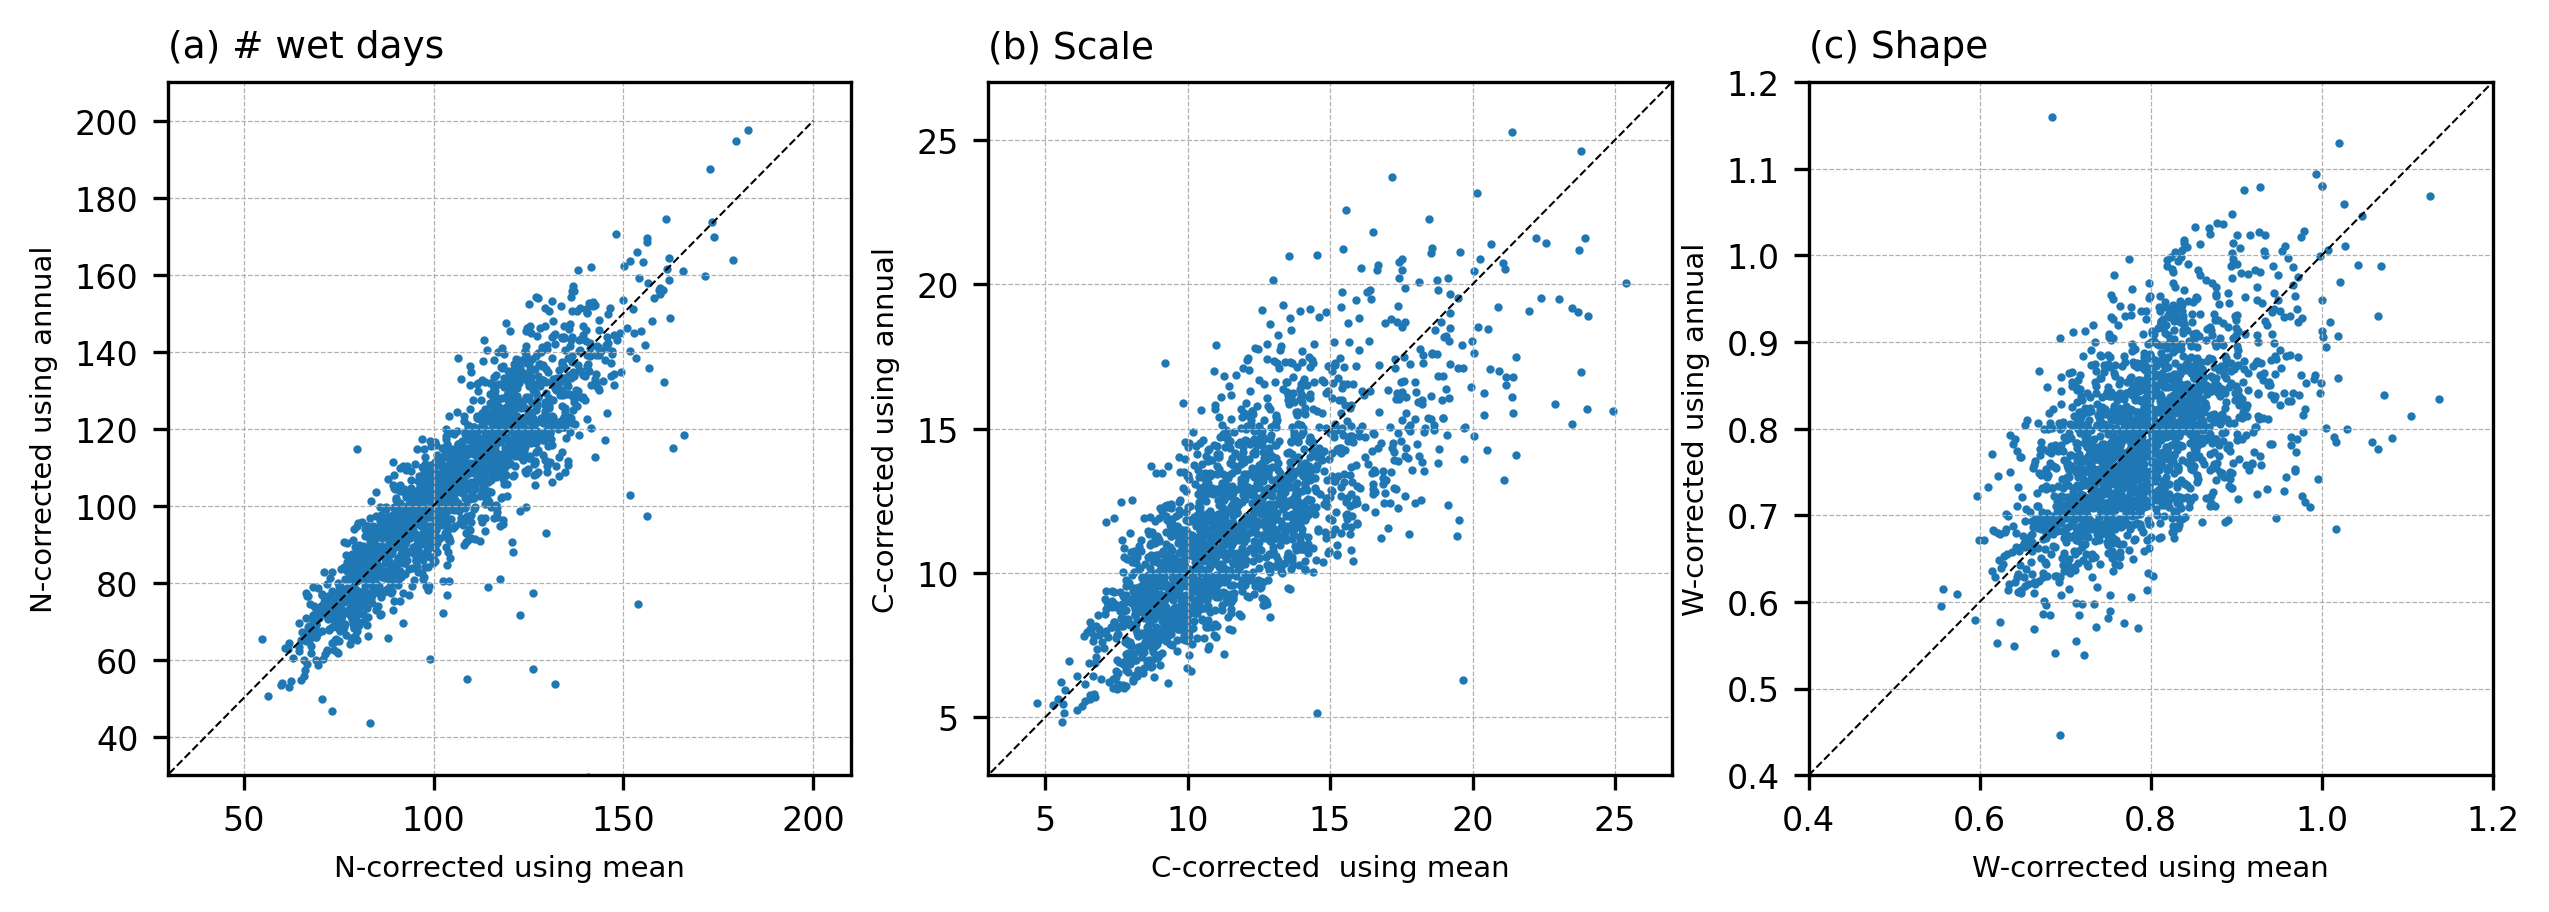

In [19]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10,3), dpi=300)
gs = gridspec.GridSpec(1, 3, figure=fig)

# ========================================================================================================
ax1 = fig.add_subplot(gs[0, 0])
x = NYs_corrected.flatten()
y = NY_corrected_annual.values.flatten()
mask_nan = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask_nan]
y_clean = y[mask_nan]
ax1.scatter(x_clean,y_clean,s=1)
xx = np.arange(10,210,10)
ax1.plot(xx,xx,linewidth=0.5,linestyle='--',c='k')
ax1.set_xlim(30,210)
ax1.set_ylim(30,210)
ax1.set_xlabel('N-corrected using mean',fontsize=7)
ax1.set_ylabel('N-corrected using annual',fontsize=7)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_title('(a) # wet days',fontsize=9,loc='left')
ax1.grid(linewidth=0.3, linestyle='--')

# ========================================================================================================
ax1 = fig.add_subplot(gs[0, 1])
x = CYs_corrected.flatten()
y = CY_corrected_annual.values.flatten()
mask_nan = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask_nan]
y_clean = y[mask_nan]
ax1.scatter(x_clean,y_clean,s=1)
xx = np.arange(2,28,1)
ax1.plot(xx,xx,linewidth=0.5,linestyle='--',c='k')
ax1.set_xlim(3,27)
ax1.set_ylim(3,27)
ax1.set_xlabel('C-corrected  using mean',fontsize=7)
ax1.set_ylabel('C-corrected using annual',fontsize=7)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_title('(b) Scale',fontsize=9,loc='left')
ax1.grid(linewidth=0.3, linestyle='--')

# ========================================================================================================
ax1 = fig.add_subplot(gs[0, 2])
x = WYs_corrected.flatten()
y = WY_corrected_annual.values.flatten()
mask_nan = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask_nan]
y_clean = y[mask_nan]
ax1.scatter(x_clean,y_clean,s=1)
xx = np.arange(0.3,1.3,0.1)
ax1.plot(xx,xx,linewidth=0.5,linestyle='--',c='k')
ax1.set_xlim(0.4,1.2)
ax1.set_ylim(0.4,1.2)
ax1.set_xlabel('W-corrected using mean',fontsize=7)
ax1.set_ylabel('W-corrected using annual',fontsize=7)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_title('(c) Shape',fontsize=9,loc='left')
ax1.grid(linewidth=0.3, linestyle='--')

In [20]:
ALL_cmap = plt.cm.Spectral_r

N_levels = np.arange(0.6,1.05,0.05)
N_norm = mcolors.BoundaryNorm(boundaries=N_levels, ncolors=ALL_cmap.N)

C_levels = np.arange(1.3,2.55,0.05)
C_norm = mcolors.BoundaryNorm(boundaries=C_levels, ncolors=ALL_cmap.N)

W_levels = np.arange(1,1.45,0.05)
W_norm = mcolors.BoundaryNorm(boundaries=W_levels, ncolors=ALL_cmap.N)

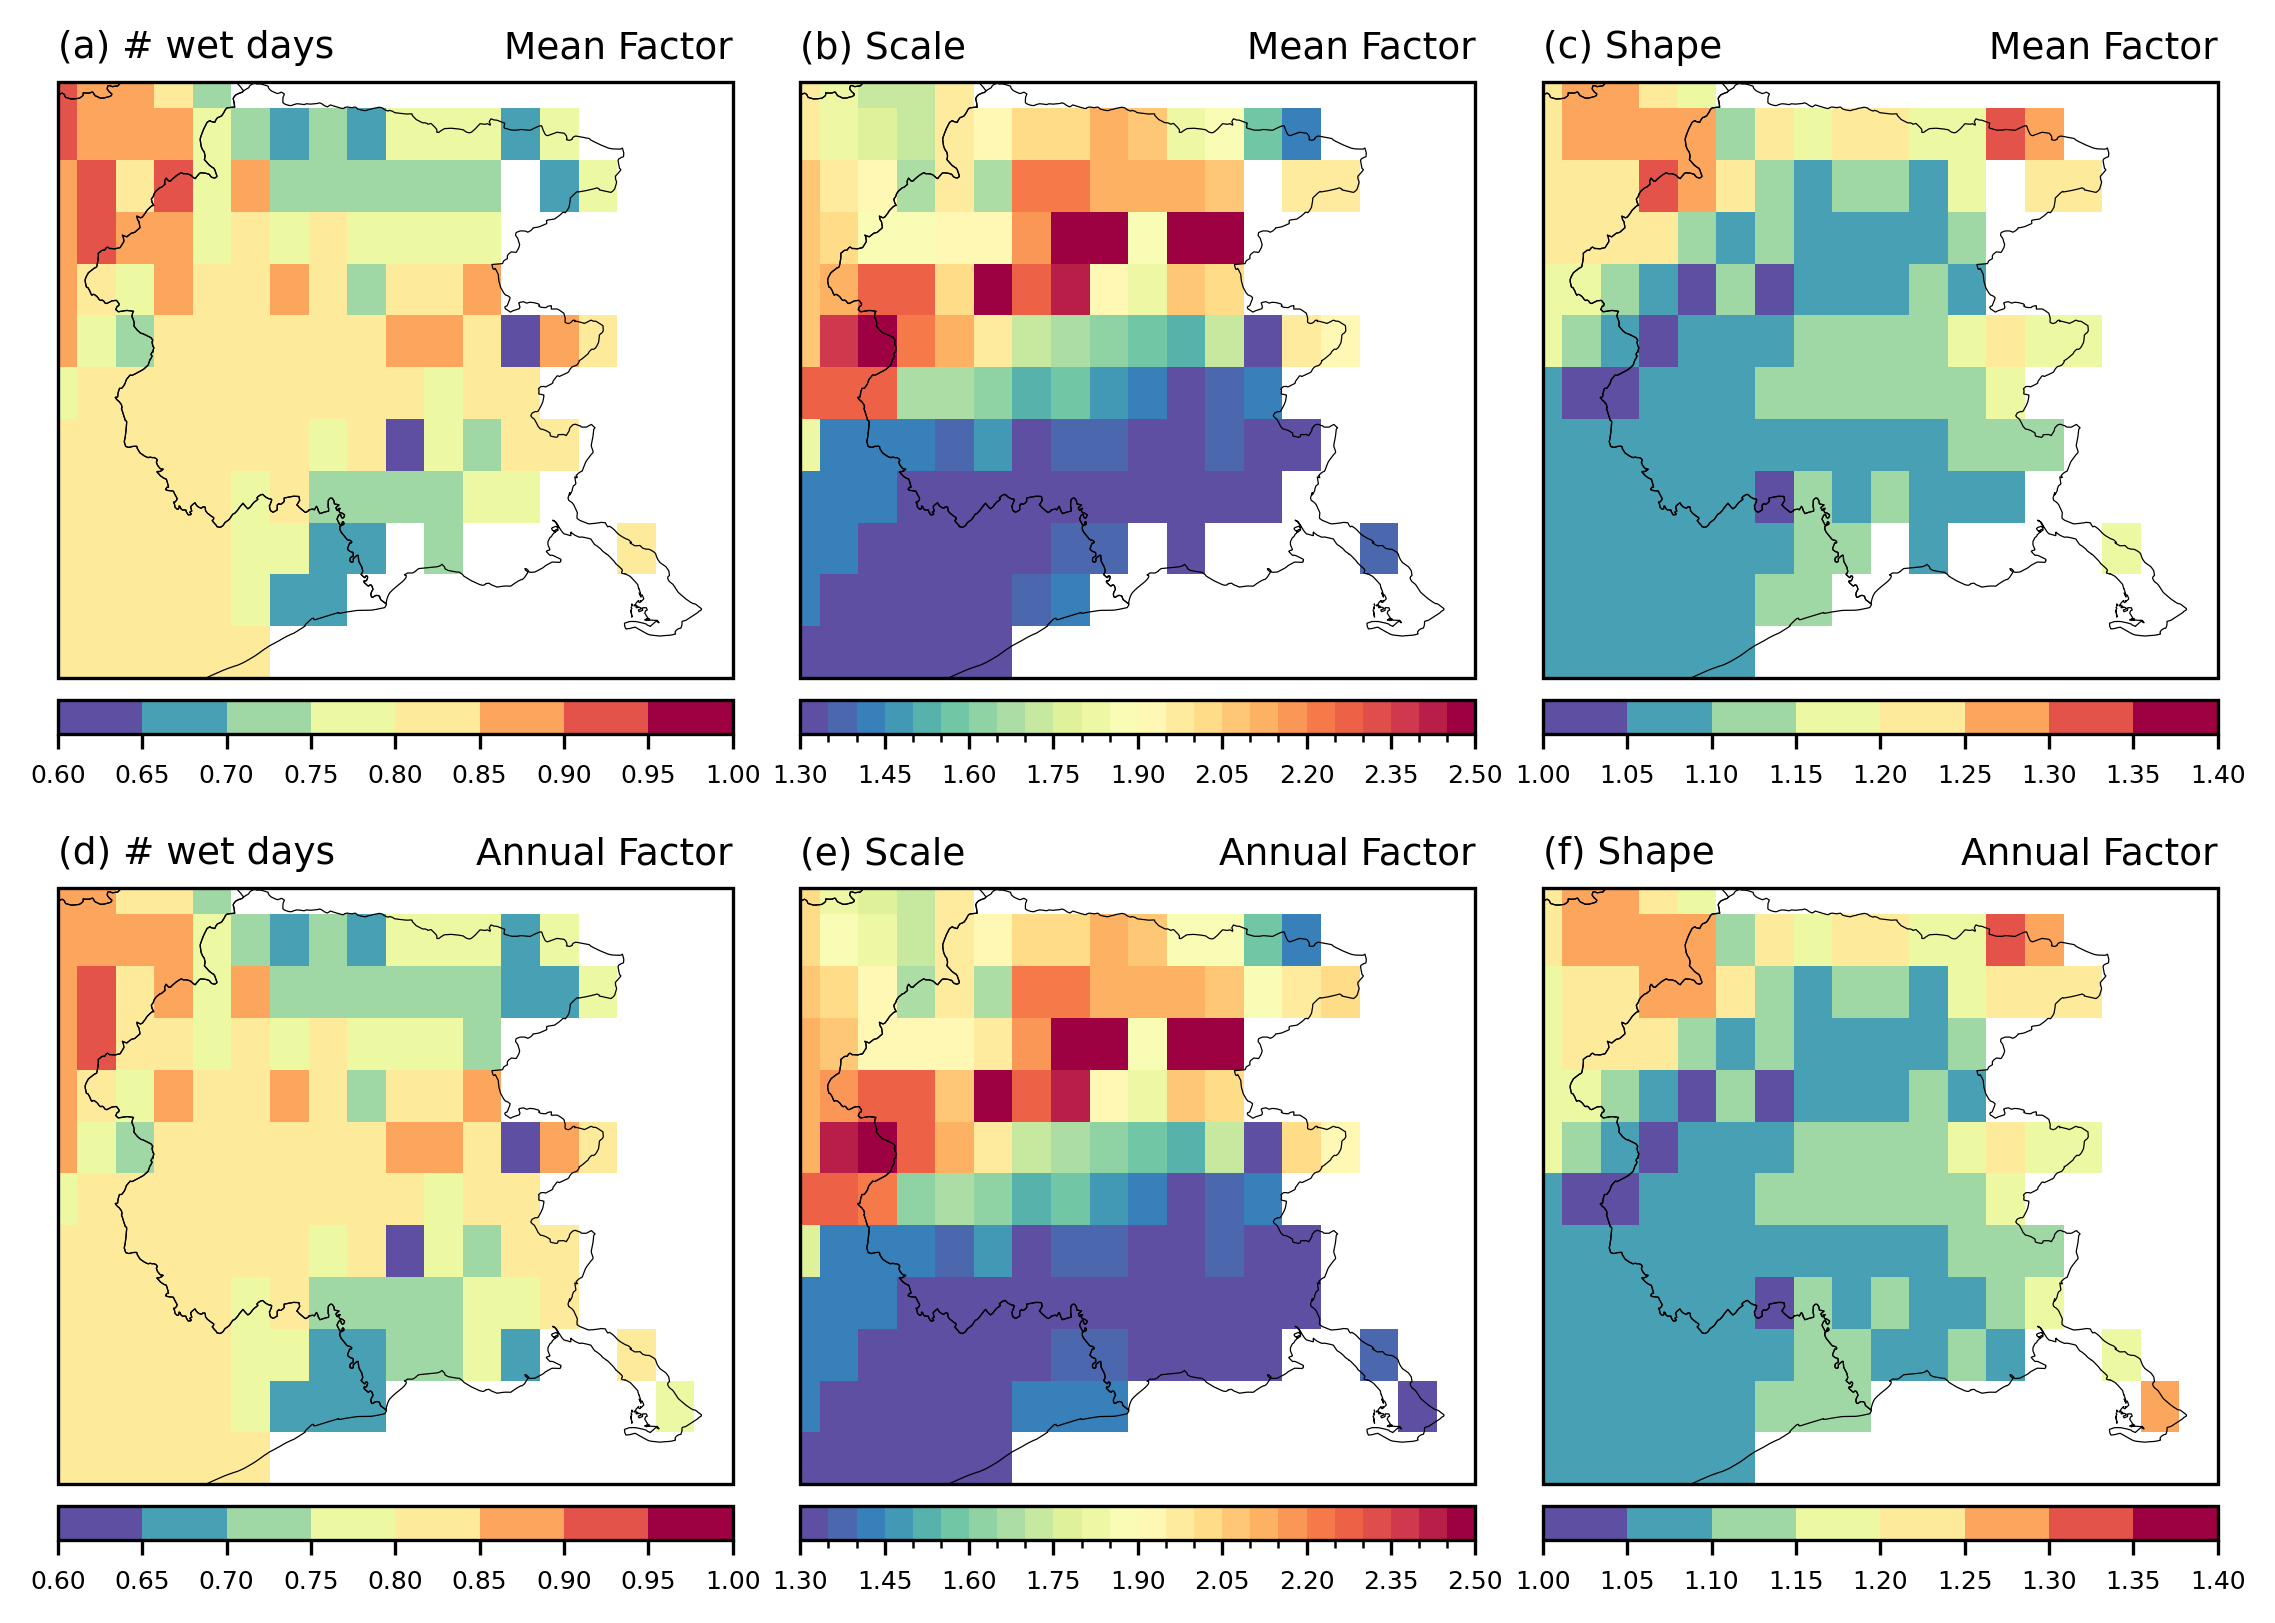

In [21]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8, 5.7), dpi=300)
gs = gridspec.GridSpec(2, 3, figure=fig)

# ========================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, Factor_N_grid, norm=N_norm, cmap=ALL_cmap)
ax00.set_title('(a) # wet days',fontsize=9,loc='left')
ax00.set_title('Mean Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 1], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, Factor_C_grid, norm=C_norm, cmap=ALL_cmap)
ax00.set_title('(b) Scale',fontsize=9,loc='left')
ax00.set_title('Mean Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 2], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, Factor_W_grid, norm=W_norm, cmap=ALL_cmap)
ax00.set_title('(c) Shape',fontsize=9,loc='left')
ax00.set_title('Mean Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

# ========================================================================================================
ax00 = fig.add_subplot(gs[1, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_N_grid,axis=0), norm=N_norm, cmap=ALL_cmap)
ax00.set_title('(d) # wet days',fontsize=9,loc='left')
ax00.set_title('Annual Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[1, 1], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_C_grid,axis=0), norm=C_norm, cmap=ALL_cmap)
ax00.set_title('(e) Scale',fontsize=9,loc='left')
ax00.set_title('Annual Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[1, 2], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_W_grid,axis=0), norm=W_norm, cmap=ALL_cmap)
ax00.set_title('(f) Shape',fontsize=9,loc='left')
ax00.set_title('Annual Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

# ========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.1, hspace=0.1)

In [22]:
RE_mean = []
Nobs_all, Cobs_all, Wobs_all = [], [], []
Ncor_all, Ccor_all, Wcor_all = [], [], []

DF_mean_individual = []

for nn in range(len(DF_20)):

    lon_obs = DF_20['Lon'].iloc[nn]
    lat_obs = DF_20['Lat'].iloc[nn]

    # Seleccionar el píxel IMERG más cercano
    sat_pixel = Corrected_mean.sel(lat=lat_obs,lon=lon_obs,method='nearest')

    N_corrected_station = sat_pixel.NYs_corrected
    C_corrected_station = sat_pixel.CYs_corrected
    W_corrected_station = sat_pixel.WYs_corrected

    # Leer datos observados
    file = DF_20['File'].iloc[nn]
    ISO = DF_20['ISO'].iloc[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

    DF_OBS = DF_OBS.drop(columns='NaN')

    # Crear DataFrame con los parámetros corregidos
    comparison_mean = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

    # Añadir parámetros observados
    comparison_mean = comparison_mean.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
    comparison_mean_clean = comparison_mean.copy()
    comparison_mean_clean = comparison_mean_clean.dropna()
    
    DF_mean_individual.append(comparison_mean.copy())

    Nobs_all.extend(comparison_mean.N.values)
    Cobs_all.extend(comparison_mean.C.values)
    Wobs_all.extend(comparison_mean.W.values)

    Ncor_all.extend(comparison_mean.N_corrected.values)
    Ccor_all.extend(comparison_mean.C_corrected.values)
    Wcor_all.extend(comparison_mean.W_corrected.values)

    x0 = np.nanmean(comparison_mean_clean.C.values)
    Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison_mean_clean.N.values, comparison_mean_clean.C.values, comparison_mean_clean.W.values, thresh=1)

    x0 = np.nanmean(comparison_mean_clean.C_corrected.values)
    Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison_mean_clean.N_corrected.values, comparison_mean_clean.C_corrected.values, comparison_mean_clean.W_corrected.values, thresh=1)

    RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
    RE_mean.append(RE_)
    
DF_mean = pd.DataFrame({'N':Nobs_all, 'C':Cobs_all, 'W':Wobs_all, 'NYs':Ncor_all, 'CYs':Ccor_all, 'WYs':Wcor_all})

In [31]:
RE_annual = []
Nobs_all, Cobs_all, Wobs_all = [], [], []
Ncor_all, Ccor_all, Wcor_all = [], [], []

DF_annual_individual = []

nn = 79

lon_obs = DF_20['Lon'].iloc[nn]
lat_obs = DF_20['Lat'].iloc[nn]

# Seleccionar el píxel IMERG más cercano
sat_pixel = Corrected_annual.sel(lat=lat_obs,lon=lon_obs,method='nearest')

N_corrected_station = sat_pixel.NYs_corrected_annual
C_corrected_station = sat_pixel.CYs_corrected_annual
W_corrected_station = sat_pixel.WYs_corrected_annual

# Leer datos observados
file = DF_20['File'].iloc[nn]
ISO = DF_20['ISO'].iloc[nn]

DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

DF_OBS = DF_OBS.drop(columns='NaN')

# Crear DataFrame con los parámetros corregidos
comparison_annual = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

# Añadir parámetros observados
comparison_annual = comparison_annual.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
comparison_annual_clean = comparison_annual.copy()
comparison_annual_clean = comparison_annual_clean.dropna()

DF_annual_individual.append(comparison_annual.copy())

Nobs_all.extend(comparison_annual.N.values)
Cobs_all.extend(comparison_annual.C.values)
Wobs_all.extend(comparison_annual.W.values)

Ncor_all.extend(comparison_annual.N_corrected.values)
Ccor_all.extend(comparison_annual.C_corrected.values)
Wcor_all.extend(comparison_annual.W_corrected.values)

x0 = np.nanmean(comparison_annual_clean.C.values)
Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N.values, comparison_annual_clean.C.values, comparison_annual_clean.W.values, thresh=1)

x0 = np.nanmean(comparison_annual_clean.C_corrected.values)
Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N_corrected.values, comparison_annual_clean.C_corrected.values, comparison_annual_clean.W_corrected.values, thresh=1)

RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
RE_annual.append(RE_)

In [ ]:
comparison_annual

,Year,N_corrected,C_corrected,W_corrected,N,C,W
0,2009,114.690308,17.274127,0.799134,112.0,16.854844,0.822873
1,2010,83.646971,11.735920,0.912172,132.0,16.461719,0.938199
2,2011,53.509459,10.056109,0.875735,85.0,12.621602,0.718585
3,2012,62.120177,11.538638,0.914345,96.0,16.386114,0.919446
4,2013,86.107176,9.084025,0.831678,131.0,13.520526,0.819357
5,2014,91.642637,10.836679,0.853541,149.0,14.187038,0.843122
6,2015,50.434203,9.518871,0.812828,81.0,12.735102,0.710994
7,2016,75.036253,9.183045,0.853363,116.0,13.810393,0.800665
8,2017,62.735228,12.002992,0.863031,97.0,17.111969,0.789026
9,2018,81.801817,6.201121,0.818834,116.0,10.817434,0.798213


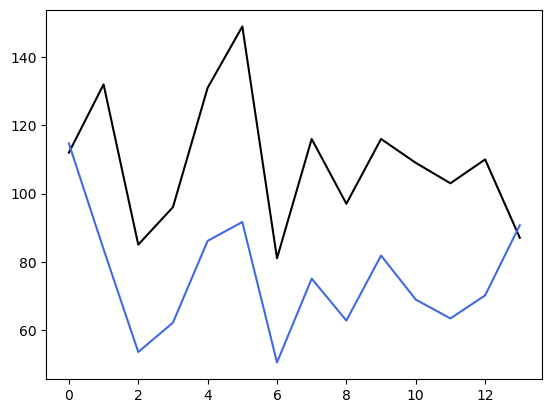

In [34]:
plt.plot(comparison_annual['N'].values, c='k', label='Obs')
plt.plot(comparison_annual['N_corrected'].values, color='royalblue', label='Mean correction')
# plt.plot(comparison_annual['N_corrected'].values, color='salmon', label='Annual correction')

In [23]:
RE_annual = []
Nobs_all, Cobs_all, Wobs_all = [], [], []
Ncor_all, Ccor_all, Wcor_all = [], [], []

DF_annual_individual = []

for nn in range(len(DF_20)):

    lon_obs = DF_20['Lon'].iloc[nn]
    lat_obs = DF_20['Lat'].iloc[nn]

    # Seleccionar el píxel IMERG más cercano
    sat_pixel = Corrected_annual.sel(lat=lat_obs,lon=lon_obs,method='nearest')

    N_corrected_station = sat_pixel.NYs_corrected_annual
    C_corrected_station = sat_pixel.CYs_corrected_annual
    W_corrected_station = sat_pixel.WYs_corrected_annual

    # Leer datos observados
    file = DF_20['File'].iloc[nn]
    ISO = DF_20['ISO'].iloc[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

    DF_OBS = DF_OBS.drop(columns='NaN')

    # Crear DataFrame con los parámetros corregidos
    comparison_annual = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

    # Añadir parámetros observados
    comparison_annual = comparison_annual.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
    comparison_annual_clean = comparison_annual.copy()
    comparison_annual_clean = comparison_annual_clean.dropna()

    DF_annual_individual.append(comparison_annual.copy())

    Nobs_all.extend(comparison_annual.N.values)
    Cobs_all.extend(comparison_annual.C.values)
    Wobs_all.extend(comparison_annual.W.values)

    Ncor_all.extend(comparison_annual.N_corrected.values)
    Ccor_all.extend(comparison_annual.C_corrected.values)
    Wcor_all.extend(comparison_annual.W_corrected.values)

    x0 = np.nanmean(comparison_annual_clean.C.values)
    Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N.values, comparison_annual_clean.C.values, comparison_annual_clean.W.values, thresh=1)

    x0 = np.nanmean(comparison_annual_clean.C_corrected.values)
    Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N_corrected.values, comparison_annual_clean.C_corrected.values, comparison_annual_clean.W_corrected.values, thresh=1)

    RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
    RE_annual.append(RE_)

DF_annual = pd.DataFrame({'N':Nobs_all, 'C':Cobs_all, 'W':Wobs_all, 'NYs':Ncor_all, 'CYs':Ccor_all, 'WYs':Wcor_all})

In [24]:
corr_mean = []
for pos in range(len(DF_20)):
    try:
        corr_mean.append(np.round(np.corrcoef(DF_annual_individual[pos]['N'].values, DF_mean_individual[pos]['N_corrected'].values)[0,1],3))
    except:
        continue
corr_mean = np.array(corr_mean)

corr_annual = []
for pos in range(len(DF_20)):
    try:
        corr_annual.append(np.round(np.corrcoef(DF_annual_individual[pos]['N'].values, DF_annual_individual[pos]['N_corrected'].values)[0,1],3))
    except:
        continue
corr_annual = np.array(corr_annual)

{'whiskers': [<matplotlib.lines.Line2D at 0x7345f01cead0>,
 'caps': [<matplotlib.lines.Line2D at 0x7345f01ced50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7345f01ce990>],
 'medians': [<matplotlib.lines.Line2D at 0x7345f01cefd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7345f01cf110>],
 'means': []}

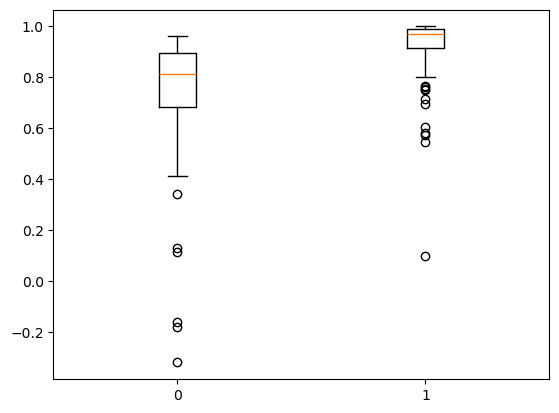

In [25]:
plt.boxplot(corr_mean[~np.isnan(corr_mean)],positions=[0])
plt.boxplot(corr_annual[~np.isnan(corr_annual)],positions=[1])

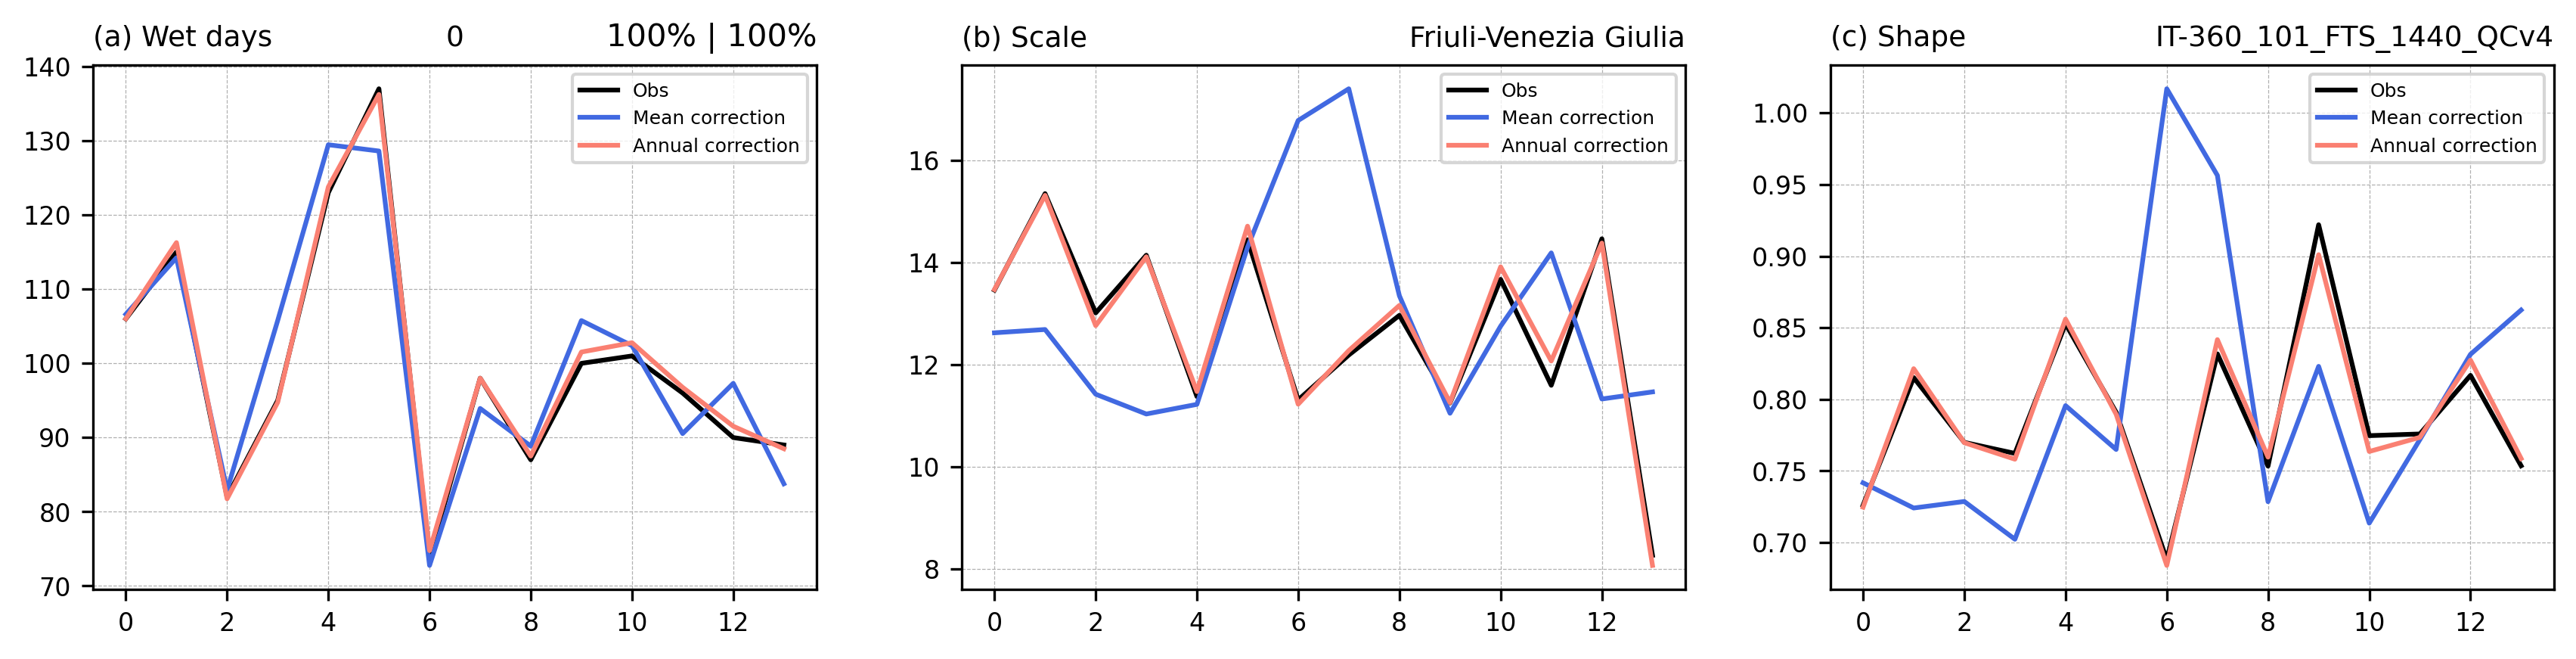

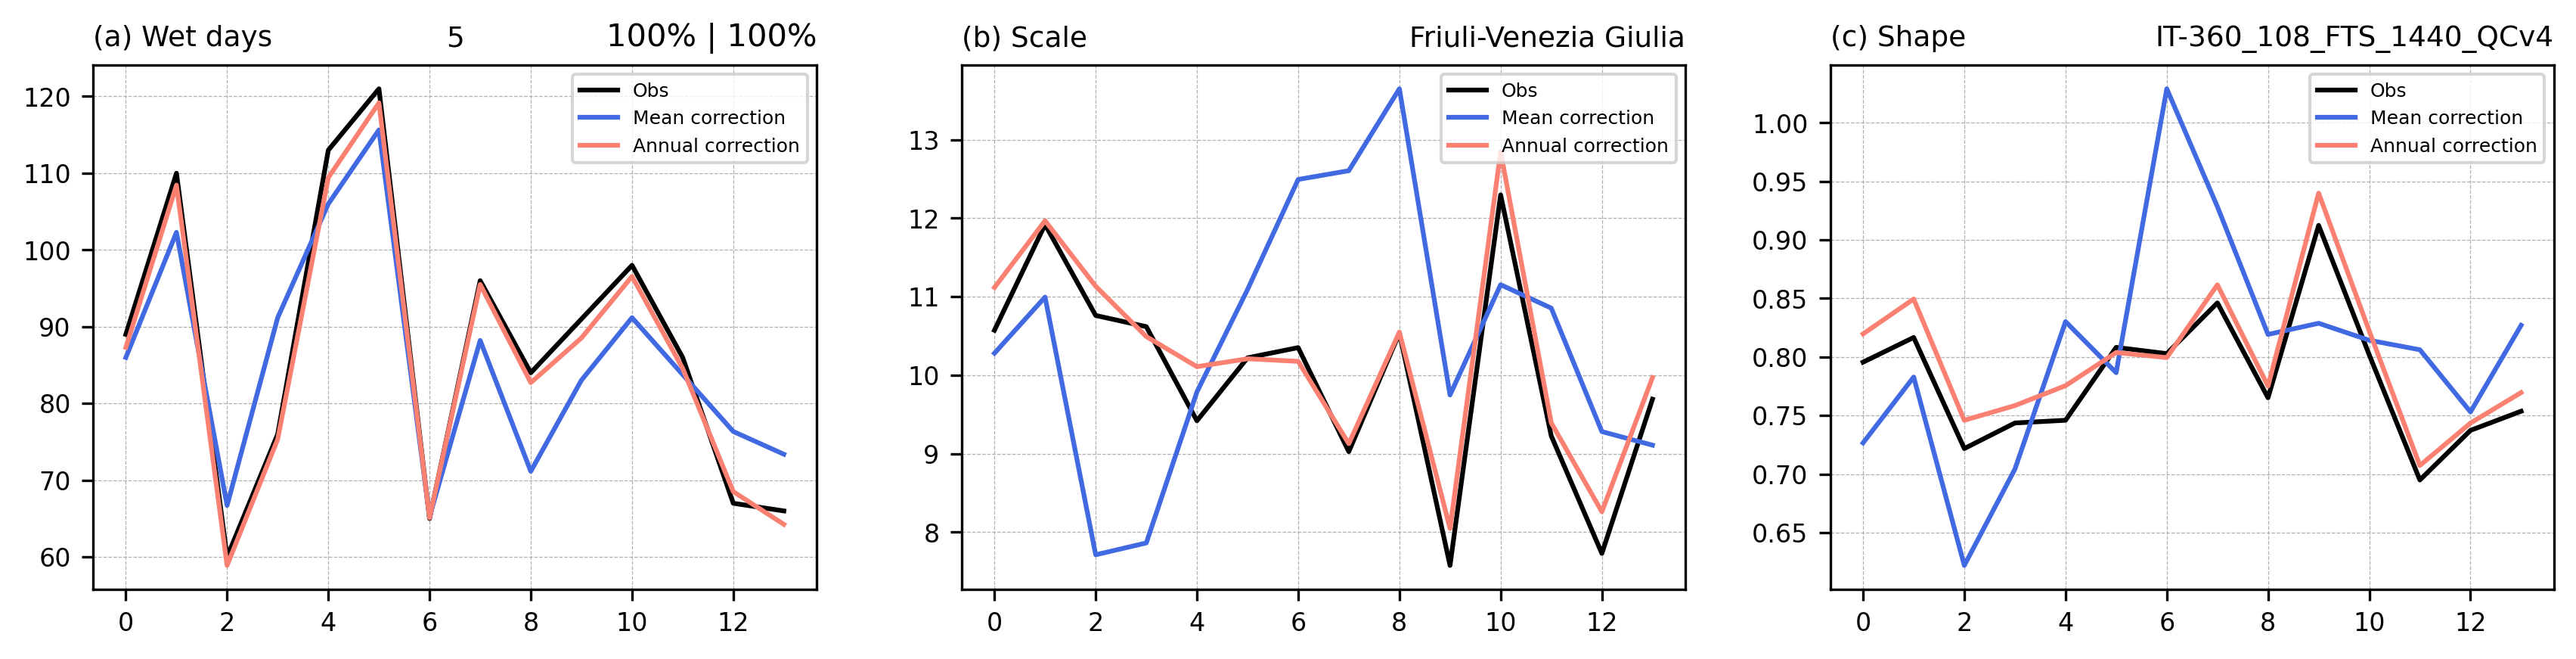

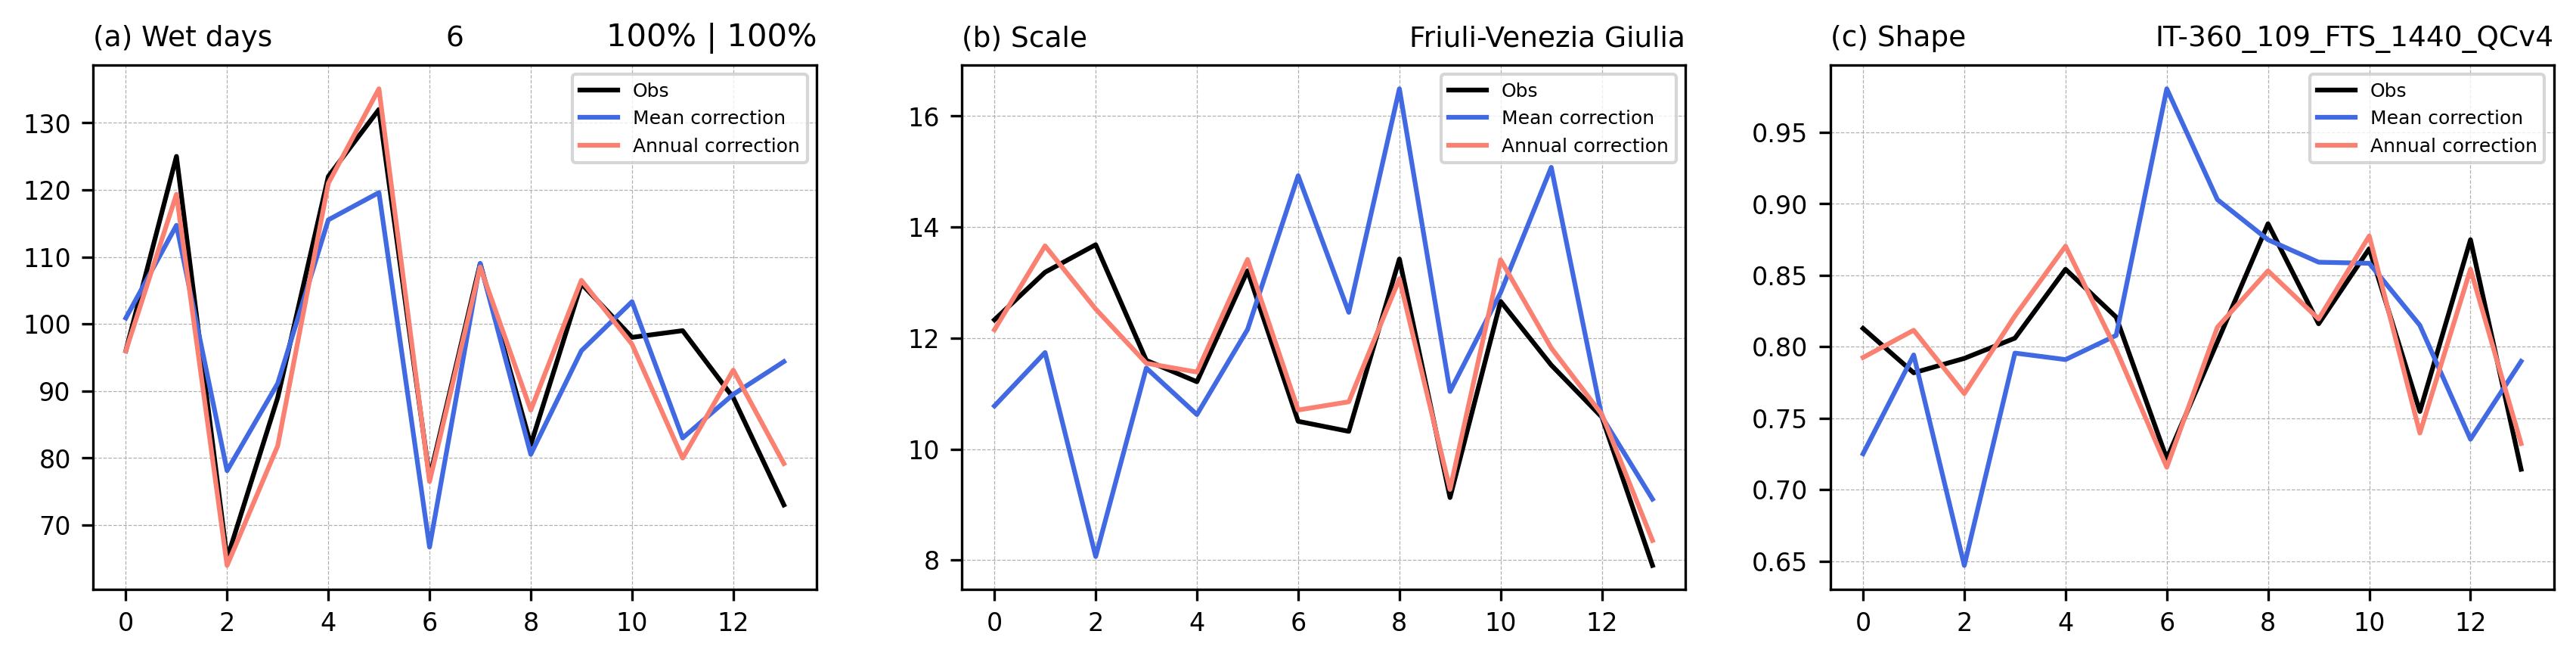

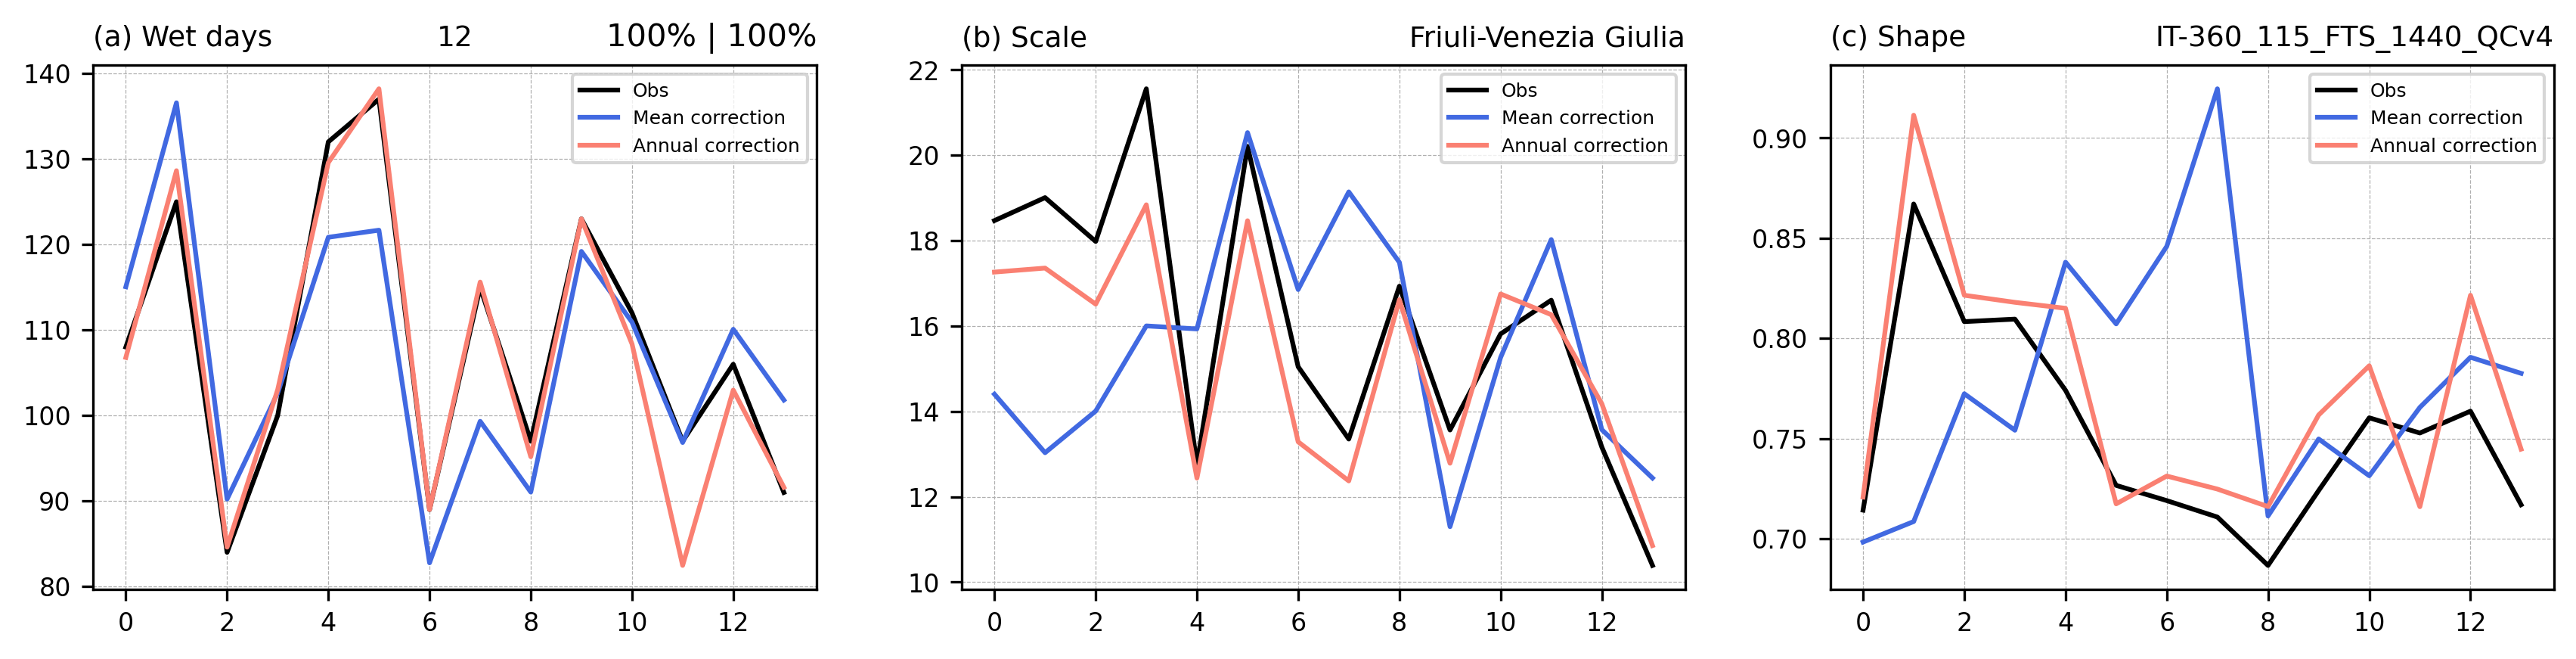

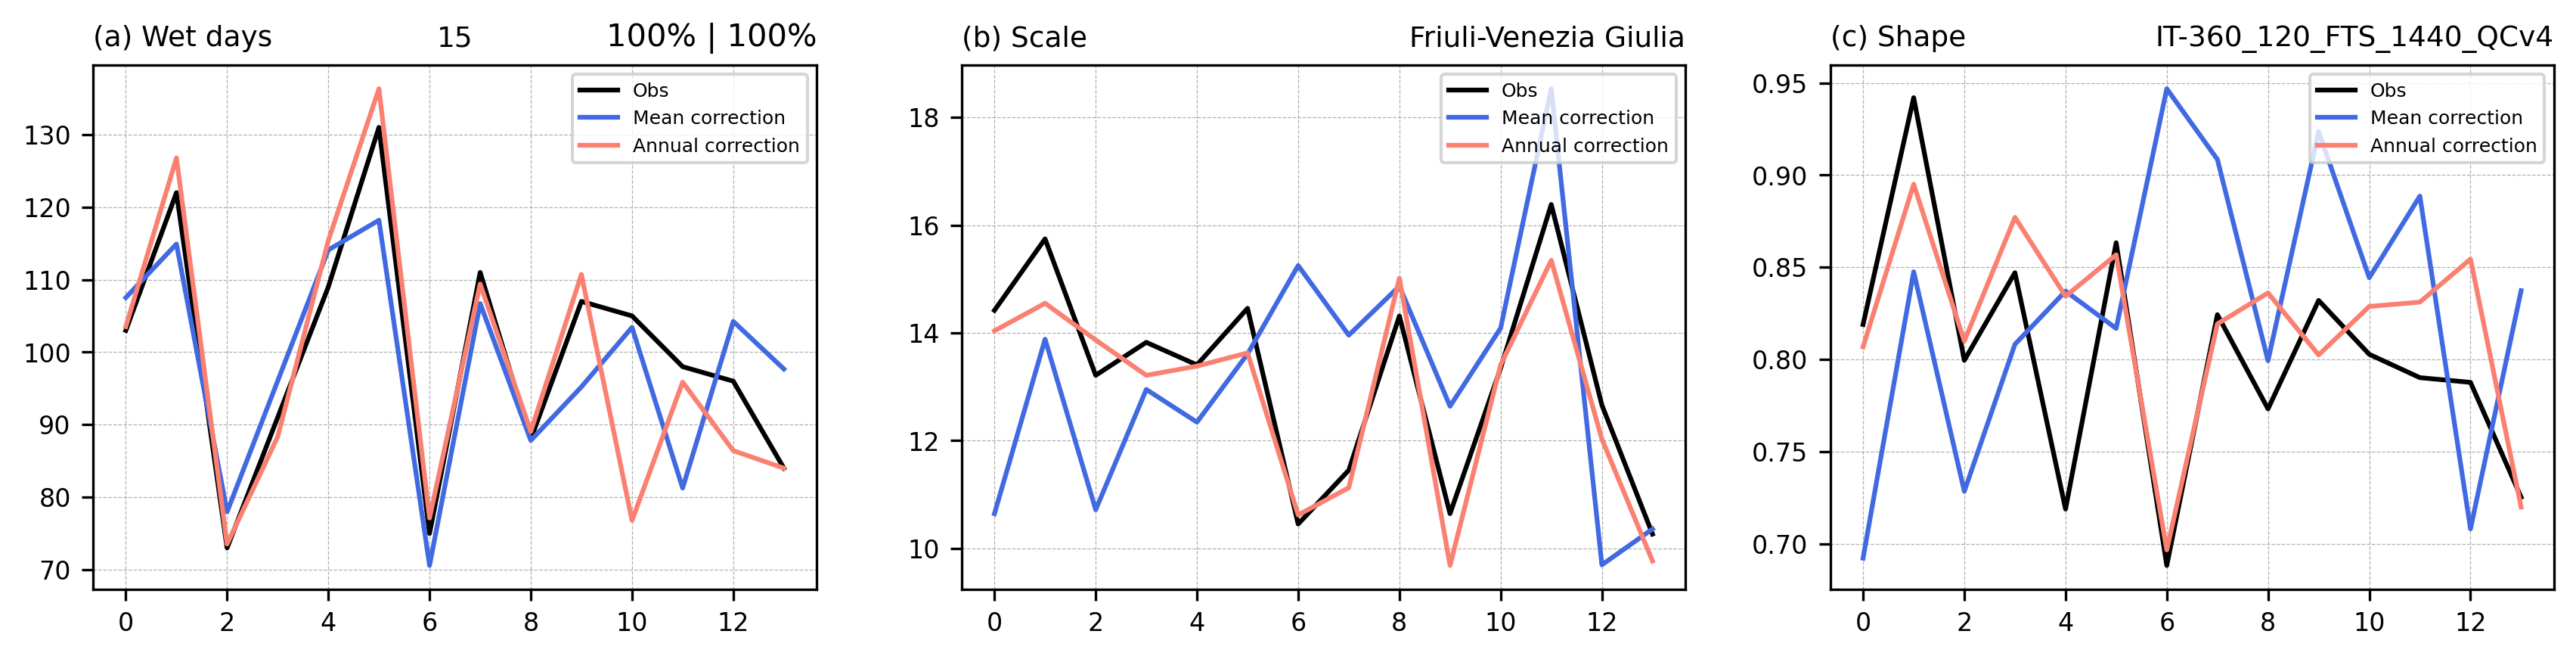

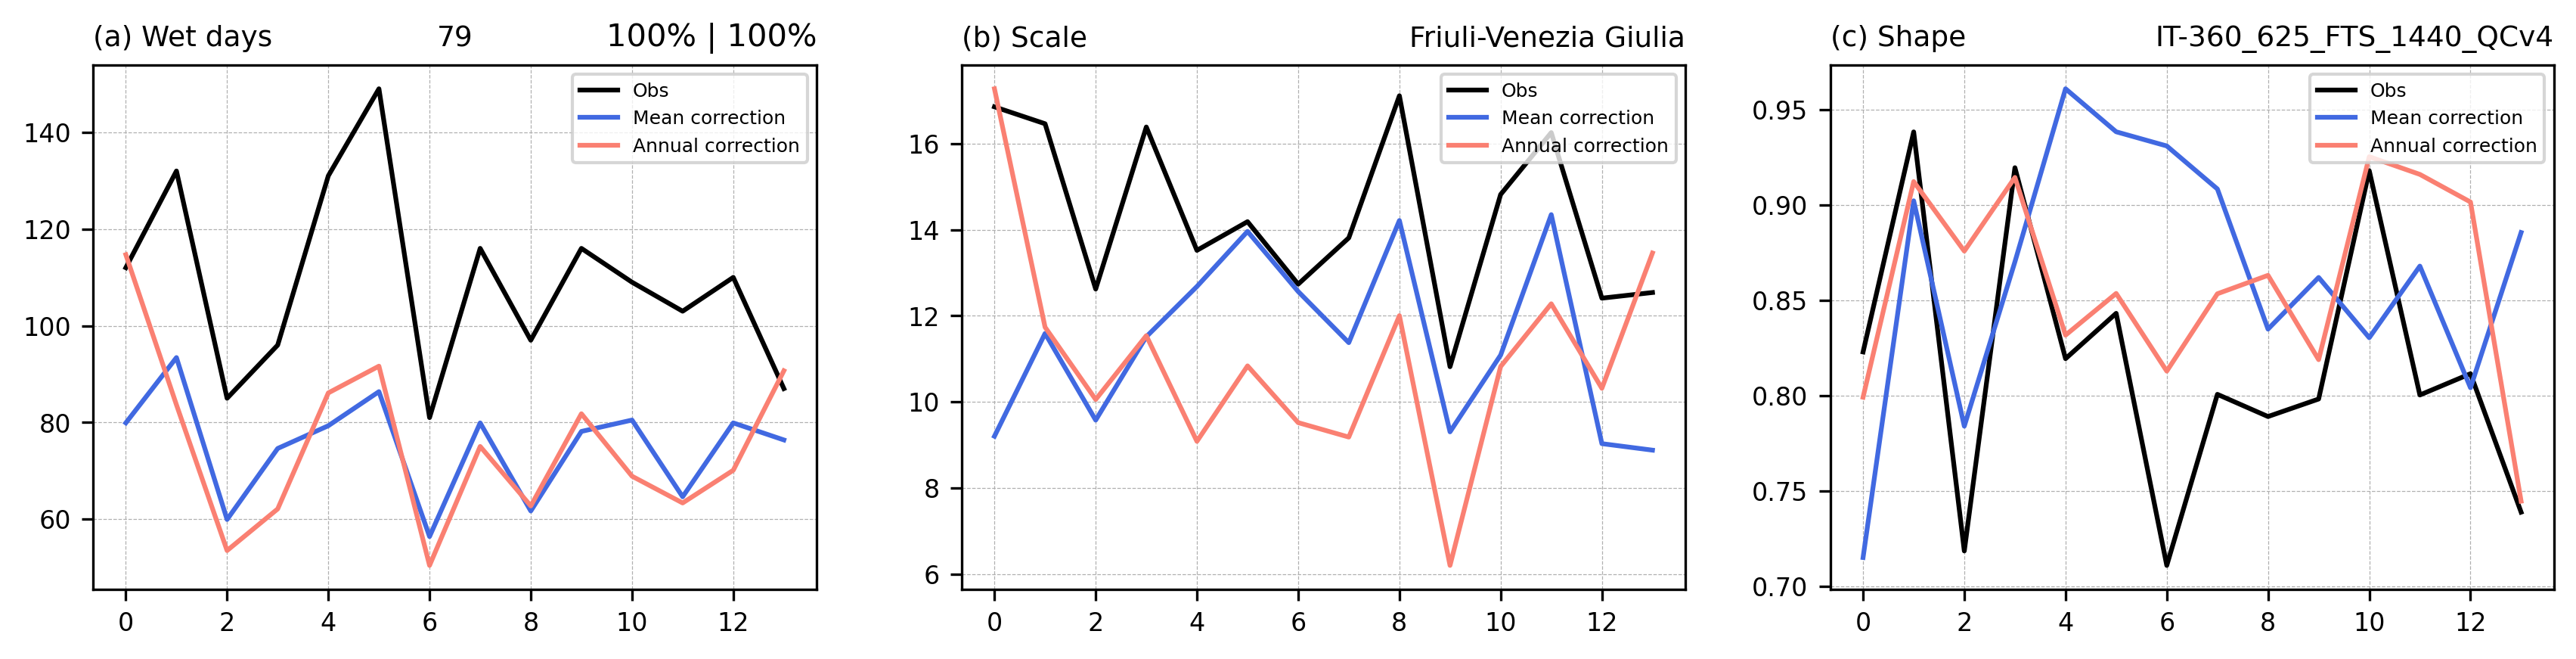

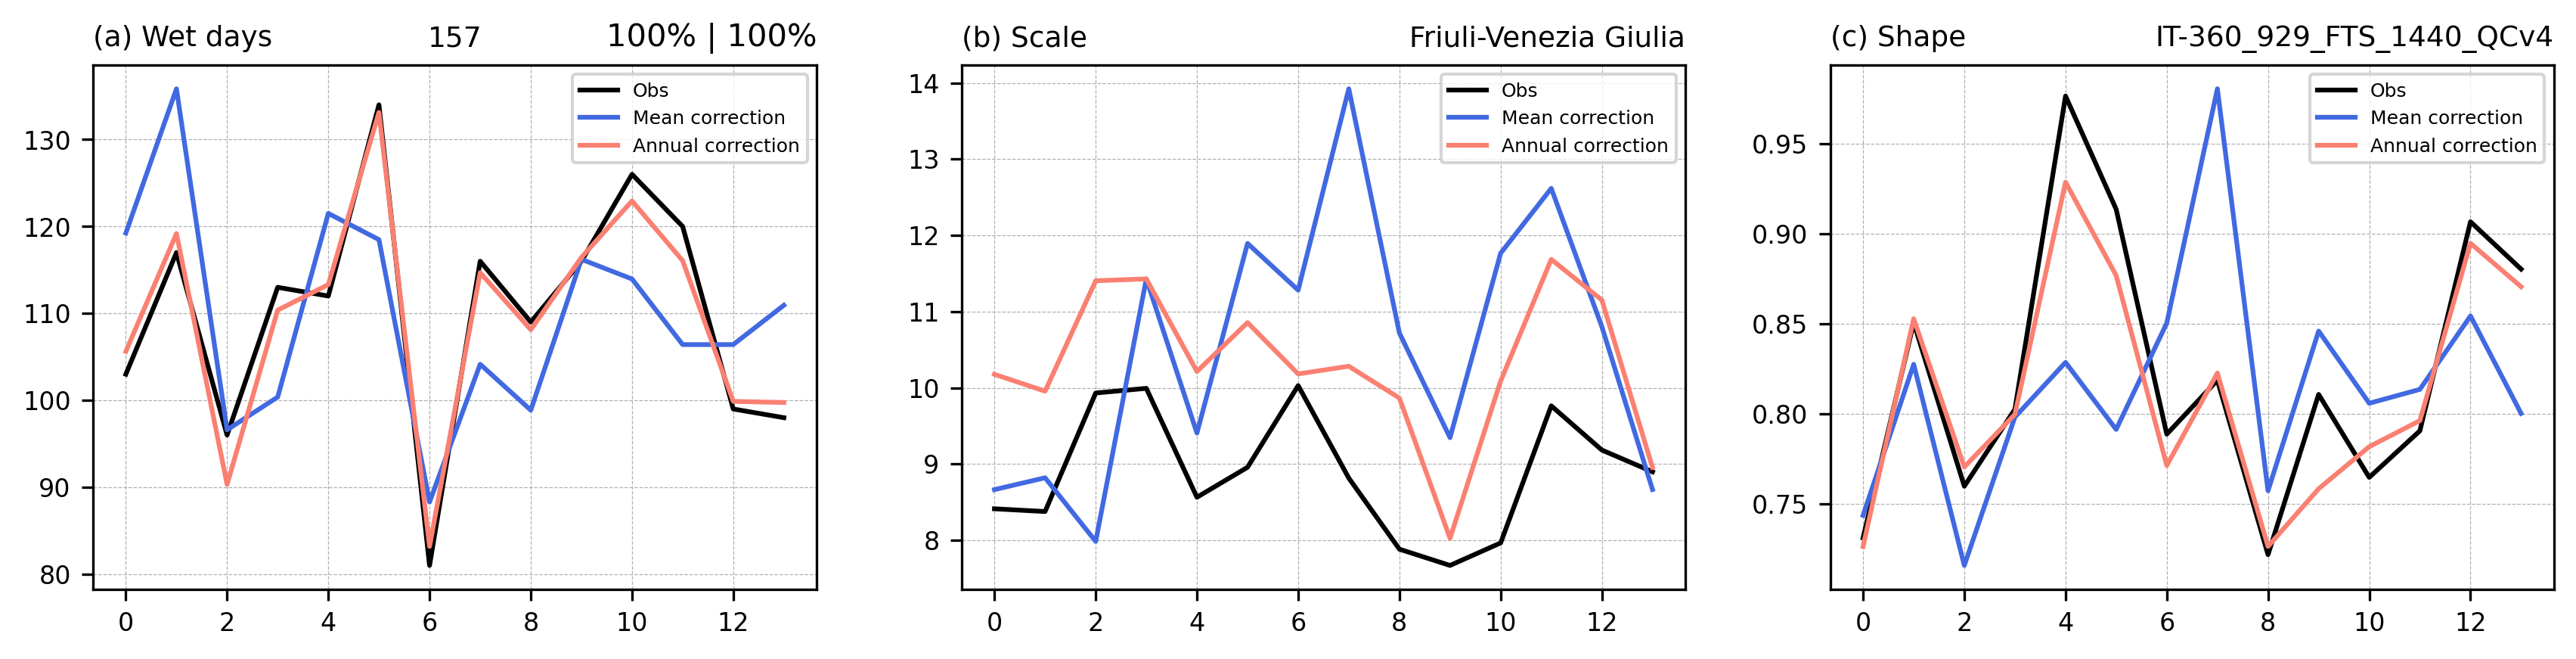

In [26]:
list_pos = [0, 5, 6, 12, 15, int(len(DF_20)/2), len(DF_20)-2]
for pos in list_pos:

    fig = plt.figure(figsize=(14,3), dpi=300)
    gs = gridspec.GridSpec(1, 3, figure=fig)

    # ========================================================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(DF_annual_individual[pos]['N'].values, c='k', label='Obs')
    ax1.plot(DF_mean_individual[pos]['N_corrected'].values, color='royalblue', label='Mean correction')
    ax1.plot(DF_annual_individual[pos]['N_corrected'].values, color='salmon', label='Annual correction')

    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_title('(a) Wet days',fontsize=9,loc='left')
    ax1.set_title(pos,fontsize=9,loc='center')
    ax1.set_title(f'{p_train}% | {p_val}%',fontsize=10, loc='right')
    ax1.grid(linewidth=0.3, linestyle='--')
    ax1.legend(fontsize=6, loc=1)

    # ========================================================================================================
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(DF_annual_individual[pos]['C'].values, c='k', label='Obs')
    ax1.plot(DF_mean_individual[pos]['C_corrected'].values, color='royalblue', label='Mean correction')
    ax1.plot(DF_annual_individual[pos]['C_corrected'].values, color='salmon', label='Annual correction')

    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_title('(b) Scale',fontsize=9,loc='left')
    ax1.set_title(area,fontsize=9, loc='right')
    ax1.grid(linewidth=0.3, linestyle='--')
    ax1.legend(fontsize=6, loc=1)

    # ========================================================================================================
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.plot(DF_annual_individual[pos]['W'].values, c='k', label='Obs')
    ax1.plot(DF_mean_individual[pos]['W_corrected'].values, color='royalblue', label='Mean correction')
    ax1.plot(DF_annual_individual[pos]['W_corrected'].values, color='salmon', label='Annual correction')

    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_title('(c) Shape',fontsize=9,loc='left')
    ax1.set_title(DF_20.File.iloc[pos].replace('.csv',''),fontsize=9, loc='right')
    ax1.grid(linewidth=0.3, linestyle='--')
    ax1.legend(fontsize=6, loc=1)

In [27]:
mask = ~(DF_mean.isna().any(axis=1) | DF_annual.isna().any(axis=1))
DF_annual = DF_annual.loc[mask].reset_index(drop=True)
DF_mean = DF_mean.loc[mask].reset_index(drop=True)

In [28]:
DF_RE = pd.DataFrame({
    'Mean': pd.Series(RE_mean, dtype='float64'),
    'Annual': pd.Series(RE_annual, dtype='float64')})
df_out = os.path.join('..','..','output','RE_bias','Fiuri_venezia',f'RE_{seed}.csv')
DF_RE.to_csv(df_out, header=True, index=False)

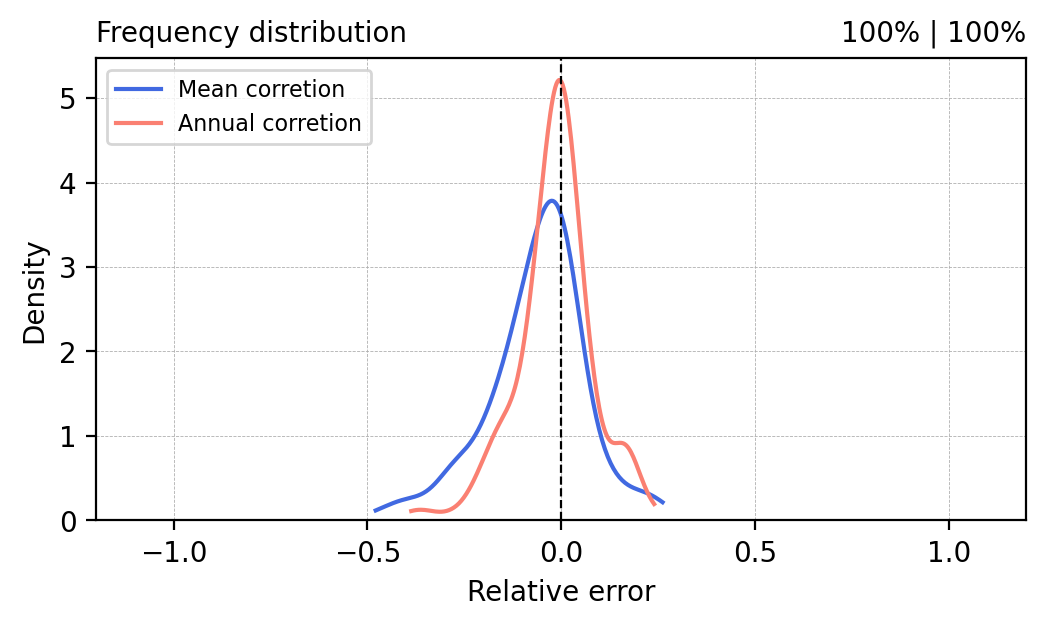

In [29]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,3),dpi=200)
gs = gridspec.GridSpec(1,1)

# ===================================================================
ax1 = plt.subplot(gs[0, 0])
sns.kdeplot(RE_mean,color='royalblue', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Mean corretion',
            clip=(np.nanmin(np.array(RE_mean)), np.nanmax(np.array(RE_mean))))
sns.kdeplot(RE_annual,color='salmon', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Annual corretion',
            clip=(np.nanmin(np.array(RE_annual)), np.nanmax(np.array(RE_annual))))
ax1.axvline(0,color='k',linestyle='--',linewidth=0.8)

ax1.set_title('Frequency distribution',fontsize=10, loc='left')
ax1.set_xlabel('Relative error', fontsize=10)
ax1.set_title(f'{p_train}% | {p_val}%',fontsize=10, loc='right')

ax1.legend(fontsize=8,loc='upper left')
ax1.set_xlim(-1.2,1.2)
ax1.grid(linewidth=0.3, linestyle='--')

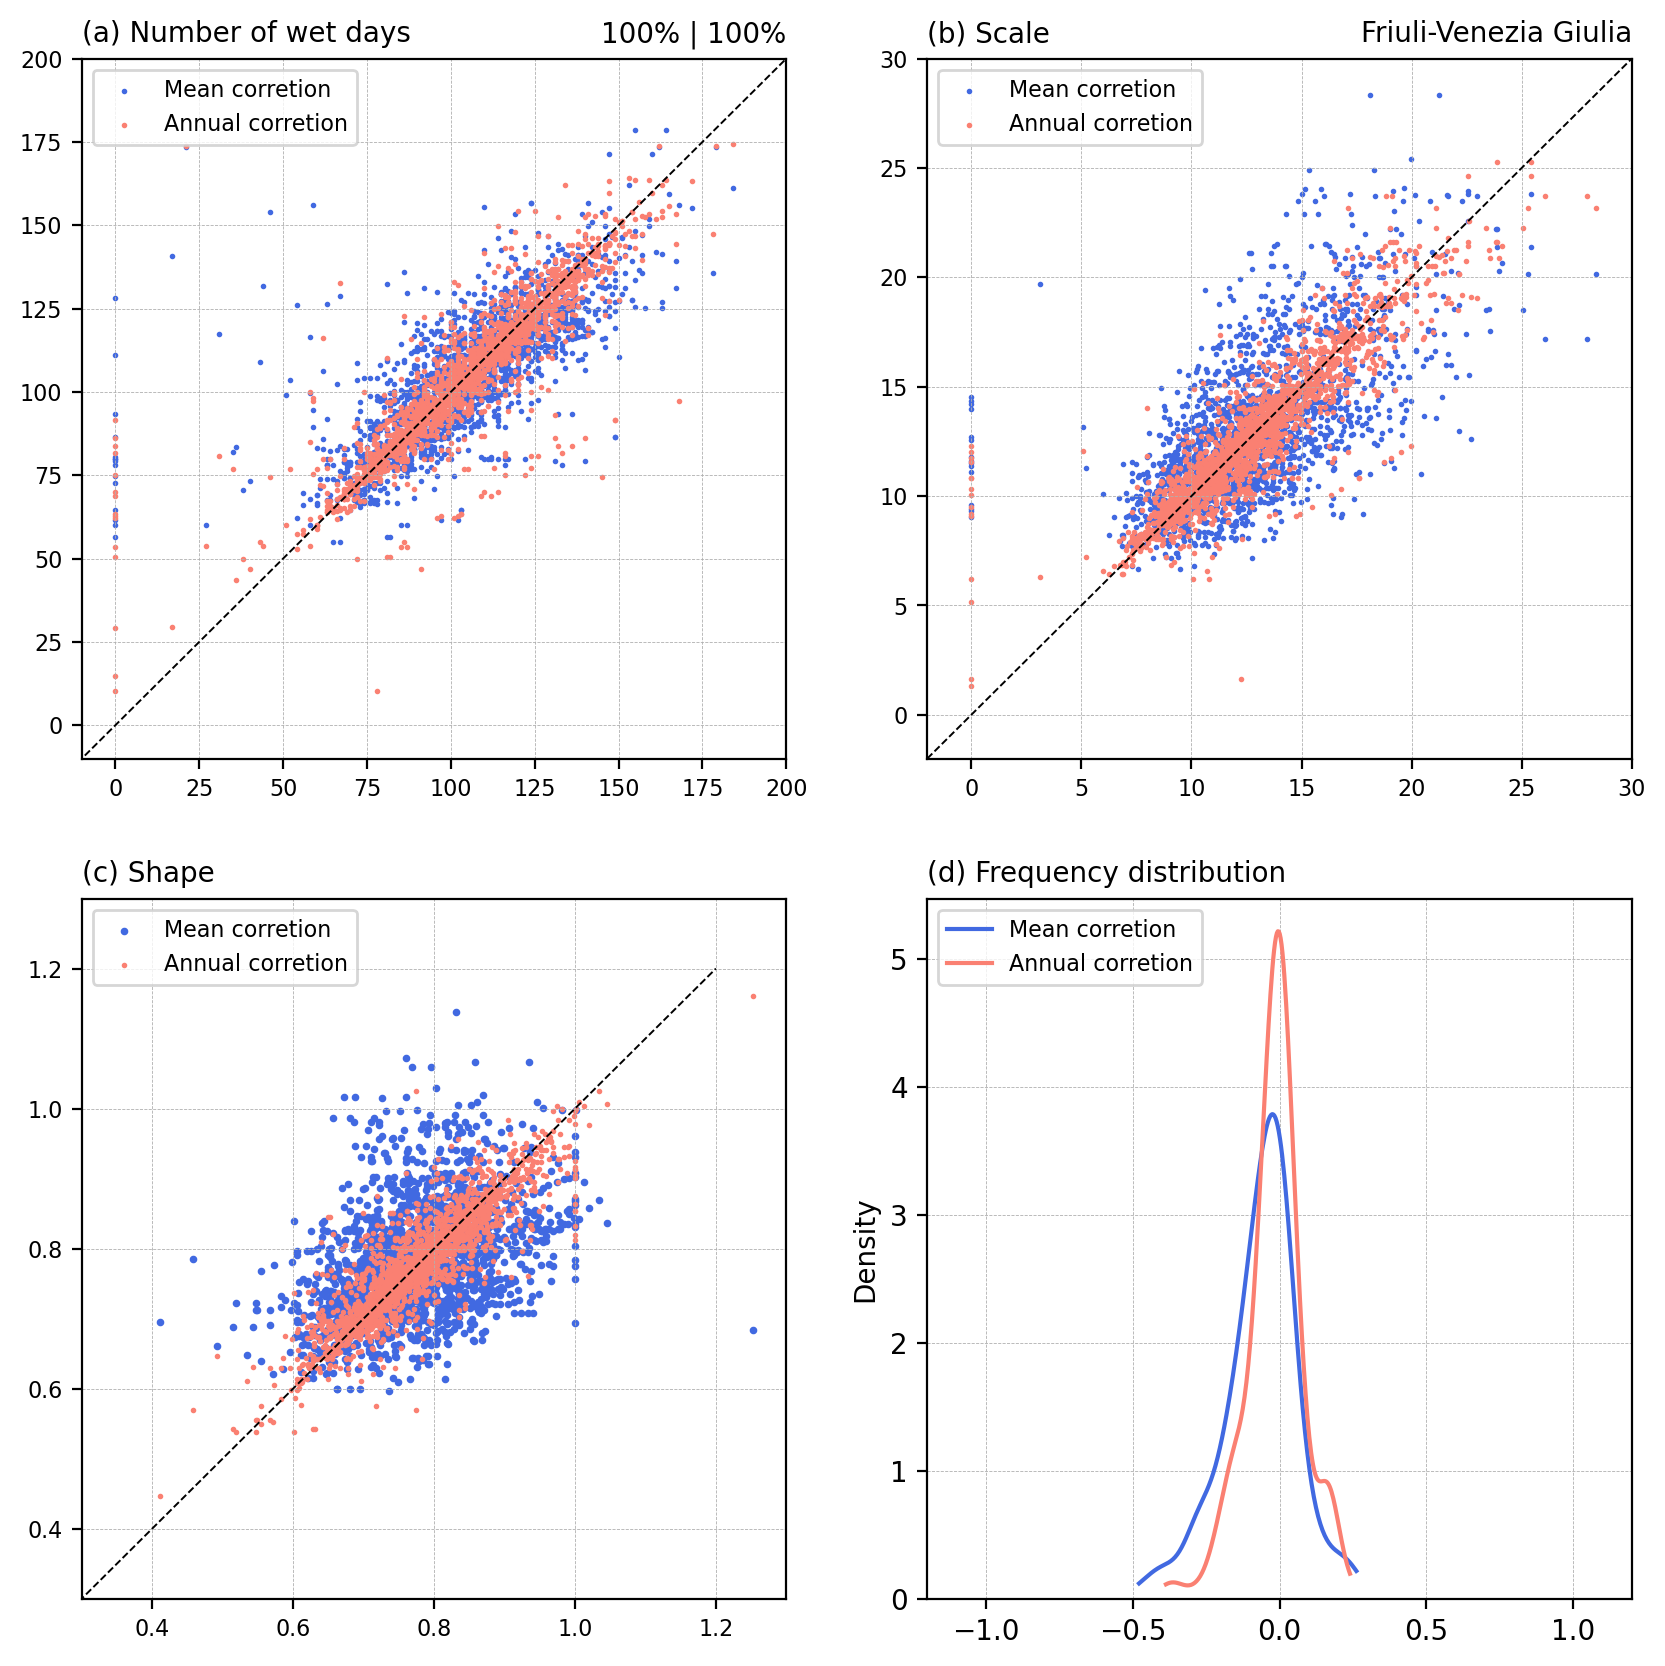

In [30]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,10),dpi=200)
gs = gridspec.GridSpec(2,2)

# ===================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(DF_mean.N, DF_mean.NYs, s=1, color='royalblue',label=f'Mean corretion')
ax1.scatter(DF_annual.N, DF_annual.NYs, s=1, color='salmon',label=f'Annual corretion')

xx = np.arange(-20, 220)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.legend(fontsize=8,loc='upper left')
ax1.set_xlim(-10,200)
ax1.set_ylim(-10,200)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Number of wet days',fontsize=10, loc='left')
ax1.set_title(f'{p_train}% | {p_val}%',fontsize=10, loc='right')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.scatter(DF_mean.C, DF_mean.CYs, s=1, color='royalblue',label=f'Mean corretion')
ax1.scatter(DF_annual.C, DF_annual.CYs, s=1, color='salmon',label=f'Annual corretion')

xx = np.arange(-3, 33)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.legend(fontsize=8,loc='upper left')
ax1.set_xlim(-2,30)
ax1.set_ylim(-2,30)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(b) Scale',fontsize=10, loc='left')
ax1.set_title(area,fontsize=10, loc='right')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===================================================================
ax1 = plt.subplot(gs[1, 0])
ax1.scatter(DF_mean.W, DF_mean.WYs, s=3, color='royalblue',label=f'Mean corretion')
ax1.scatter(DF_annual.W, DF_annual.WYs, s=1, color='salmon',label=f'Annual corretion')

xx = np.arange(0.2, 1.4)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.legend(fontsize=8,loc='upper left')
ax1.set_xlim(0.3,1.3)
ax1.set_ylim(0.3,1.3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(c) Shape',fontsize=10, loc='left')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===================================================================
ax1 = plt.subplot(gs[1, 1])
sns.kdeplot(RE_mean,color='royalblue', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Mean corretion',
            clip=(np.nanmin(np.array(RE_mean)), np.nanmax(np.array(RE_mean))))
sns.kdeplot(RE_annual,color='salmon', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Annual corretion',
            clip=(np.nanmin(np.array(RE_annual)), np.nanmax(np.array(RE_annual))))

ax1.set_title('(d) Frequency distribution',fontsize=10, loc='left')

ax1.legend(fontsize=8,loc='upper left')
ax1.set_xlim(-1.2,1.2)
ax1.grid(linewidth=0.3, linestyle='--')